# KdV Equation - S4/S4D Sequence Modeling

This notebook trains **S4** and **S4D** on full sensor trajectories to predict POD coefficients at every time step (sequence-to-sequence).

$$u_t + 6uu_x + u_{xxx} = 0$$

## 1. Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'scripts'))
sys.path.insert(0, str(project_root / 'utils'))

from kdv import kdv_etdrk4

np.random.seed(64)
torch.manual_seed(64)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 2. Generate KdV Trajectories

In [2]:
import time
from scipy.interpolate import make_interp_spline

Lx = 15.0
Nx = 256
dt = 0.01
Tfinal = 20.0
steps = int(round(Tfinal / dt))
save_every = 5
Nt = steps // save_every +1
n_total = 50

x = np.linspace(0, Lx, Nx, endpoint=False)
t_grid = np.linspace(0, Tfinal, Nt)
rng = np.random.default_rng(42)

def ic_spline(x, n_control=8, rng=rng):
    xp = np.linspace(0, Lx, n_control + 1)
    yp = rng.uniform(0, 1, n_control + 1)
    yp[-1] = yp[0]
    cs = make_interp_spline(xp, yp, bc_type='periodic', k=4)
    return cs(x).astype(np.float64)

def ic_fourier(x, Kmax=8, rng=rng):
    u = np.zeros(len(x))
    for k in range(1, Kmax + 1):
        a = rng.normal(0, 1.0 / k**2)
        b = rng.normal(0, 1.0 / k**2)
        u += a * np.cos(2 * np.pi * k * x / Lx) + b * np.sin(2 * np.pi * k * x / Lx)
    return u.astype(np.float64)

def ic_mixed(x, rng=rng):
    alpha = rng.uniform(0.3, 0.6)
    return alpha * ic_spline(x, rng=rng) + (1 - alpha) * ic_fourier(x, rng=rng)

def soliton(x, t, c=1.0, x0=rng.uniform(0, Lx)):
    return 0.5 * c * np.cosh(0.5 * np.sqrt(c) * (x - c * t - x0))**(-2)


def random_solitons(x, t, n_solitons=3, rng=rng):
    u = np.zeros_like(x)
    for _ in range(n_solitons):
        c = rng.uniform(0.1, 2.0)
        x0 = rng.uniform(0, Lx)
        u += soliton(x, t, c=c, x0=x0)
    return u.astype(np.float64)


def generate_kdv_data(inital_condition, n_points = 8, ntrajectories = 200, nx=128, dt = 0.01, Lx=10*np.pi, T=20.0, device = 'cpu', q= -6.00, random_q = False, random_degree = False, save_every = 20, random_state = 42):
    """
    Generate KdV simulation data for neural network training.
    
    Args:
        inital_condition: function that generates initial conditions given spatial grid
        ntrajectories: Number of trajectories to simulate
        nx: Number of spatial grid points
        dt: Time step size
        Lx: Spatial domain length
        T: Final time

    Returns:
        dict: Dictionary containing:
            
            - 'snapshots': Solution snapshots (n_trajectories, nt, nx)
            - 'stacked_space': Spatial coordinates (n_trajectories, nt, nx)
            - 'stacked_time': Time coordinates (n_trajectories, nt, nx)
    """
    
    
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    snapshots = []
    stacked_time = []
    stacked_space = []
    
    max_attempts = 10
    x = np.linspace(0, Lx, nx, endpoint=False)

    steps = int(T/dt)
    
    if random_q:
        Q = np.random.random_integers(3,7, ntrajectories)
    else:
        Q = q * np.ones(ntrajectories)
    for i in range(ntrajectories):
        if random_degree:
            n_points = np.random.randint(2,8)
        for attempt in range(max_attempts):
            try:
                u0_i = inital_condition(x, n_points)
                sol = kdv_etdrk4(
                    u0=u0_i, Lx=Lx, dt=dt, steps=steps,
                    save_every=save_every, dealias=True, M_phi=32, progress=False, q = Q[i]
                )
                snapshots.append(sol.u)
                print(f"Trajectory {i+1}: Success on attempt {attempt+1}")


                break
            except RuntimeError as e:
                print(f"Trajectory {i+1}, attempt {attempt+1} failed: {e}")
            except ValueError as e:
                print(f"Trajectory {i+1}, attempt {attempt+1} failed: {e}")
        else:
            print(f"Trajectory {i+1}: All attempts failed. Skipping.")

    # Stack all snapshots into a matrix (shape: [num_snapshots, spatial_dim])
    
    snapshots = np.stack(snapshots, axis=0)     
    return snapshots

snaps = generate_kdv_data(ic_spline, n_points=6, ntrajectories=n_total, nx=Nx, dt=dt, Lx=Lx, T=Tfinal, device=device, q=-6.0, random_q=True, random_degree=True, save_every=save_every)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.9)
snaps_train = snaps[:n_train]
snaps_val = snaps[n_train:n_val]
snaps_test = snaps[n_val:]

Trajectory 1: Success on attempt 1
Trajectory 2: Success on attempt 1
Trajectory 3: Success on attempt 1
Trajectory 4: Success on attempt 1
Trajectory 5: Success on attempt 1
Trajectory 6: Success on attempt 1
Trajectory 7: Success on attempt 1
Trajectory 8: Success on attempt 1
Trajectory 9: Success on attempt 1
Trajectory 10: Success on attempt 1
Trajectory 11: Success on attempt 1
Trajectory 12: Success on attempt 1
Trajectory 13: Success on attempt 1
Trajectory 14: Success on attempt 1
Trajectory 15: Success on attempt 1
Trajectory 16: Success on attempt 1
Trajectory 17: Success on attempt 1
Trajectory 18: Success on attempt 1
Trajectory 19: Success on attempt 1
Trajectory 20: Success on attempt 1
Trajectory 21: Success on attempt 1
Trajectory 22: Success on attempt 1
Trajectory 23: Success on attempt 1
Trajectory 24: Success on attempt 1
Trajectory 25: Success on attempt 1
Trajectory 26: Success on attempt 1
Trajectory 27: Success on attempt 1
Trajectory 28: Success on attempt 1
T

Training trajectories: (40, 401, 256), Validation trajectories: (5, 401, 256), Test trajectories: (5, 401, 256)


Text(0.5, 1.0, 'Sample KdV Trajectory')

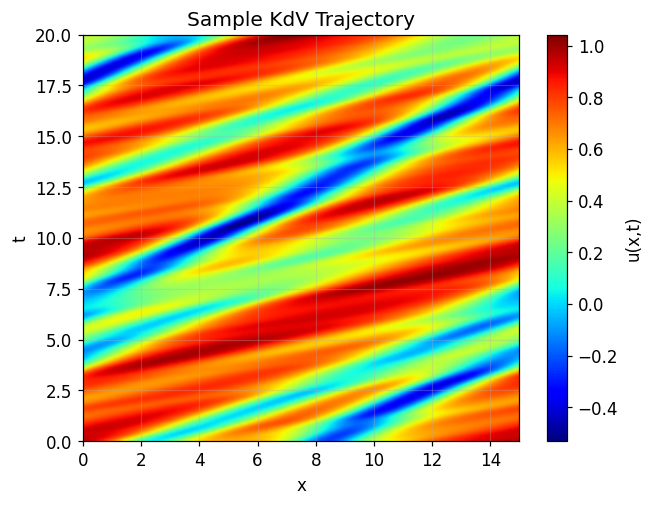

In [3]:
print(f"Training trajectories: {snaps_train.shape}, Validation trajectories: {snaps_val.shape}, Test trajectories: {snaps_test.shape}")
i = np.random.randint(0, len(snaps_train))
plt.imshow(snaps[i, :200, :], aspect='auto', extent=[0, Lx, 0, Tfinal],  cmap='jet', interpolation= 'bicubic')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Sample KdV Trajectory')  

## 3. POD and Full-Sequence Dataset

In [4]:
snap_mat = snaps_train.reshape(-1, Nx).astype(np.float64)
_, S_full, Vt = randomized_svd(snap_mat, n_components=50, random_state=42)
energy = np.cumsum(S_full**2) / np.sum(S_full**2)
r_auto = int(np.searchsorted(energy, 0.99)) + 1
n_modes = max(r_auto, 8)
Phi = Vt[:n_modes].T
print(f'POD modes: {n_modes}, energy={100*energy[n_modes-1]:.2f}%')
print(f'Reconstruction rmrse with {n_modes} modes: {np.mean(np.sqrt(np.sum((snap_mat - snap_mat @ Phi @ Phi.T)**2, axis = -1)) / np.sqrt(np.sum(snap_mat**2, axis=-1)))*100:.4e}')

modes_train = snaps_train @ Phi
modes_val = snaps_val @ Phi
modes_test = snaps_test @ Phi

n_sensors = 5
sensor_pos = [int((i + 1) * Nx / (n_sensors + 1)) for i in range(n_sensors)]
sensor_pos += np.random.normal(0, 10, n_sensors).astype(int)
sensor_x = x[sensor_pos]
print(f"Sensor positions (x): {sensor_x}")
scaler = StandardScaler()
scaler.fit(modes_train.reshape(-1, n_modes))
A_train_sc = scaler.transform(modes_train.reshape(-1, n_modes)).reshape(n_train, Nt, n_modes)
A_val_sc = scaler.transform(modes_val.reshape(-1, n_modes)).reshape(int(0.1 * n_total), Nt, n_modes)
A_test_sc = scaler.transform(modes_test.reshape(-1, n_modes)).reshape(int(0.1 * n_total), Nt, n_modes)

X_train = snaps_train[:, :, sensor_pos].astype(np.float32)
Y_train = A_train_sc.astype(np.float32)
X_val = snaps_val[:, :, sensor_pos].astype(np.float32)
Y_val = A_val_sc.astype(np.float32)
X_test = snaps_test[:, :, sensor_pos].astype(np.float32)
Y_test = A_test_sc.astype(np.float32)   

POD modes: 8, energy=99.33%
Reconstruction rmrse with 8 modes: 6.5610e+00
Sensor positions (x): [ 2.98828125  5.33203125  7.8515625  10.01953125 12.83203125]


## 4. HiPPO Utilities

In [5]:
def make_hippo_legs(N):
    A = np.zeros((N, N))
    B = np.zeros((N, 1))
    for n in range(N):
        B[n, 0] = (2 * n + 1) ** 0.5
        for k in range(N):
            if n > k:
                A[n, k] = -(2 * n + 1) ** 0.5 * (2 * k + 1) ** 0.5
            elif n == k:
                A[n, k] = -(n + 1)
    return A, B

def discretize_bilinear(A, B, step):
    N = A.shape[0]
    I = np.eye(N)
    Ainv = np.linalg.solve(I - A * step / 2, I)
    Ad = Ainv @ (I + A * step / 2)
    Bd = (Ainv * step) @ B
    return Ad, Bd

## 5. S4,  S4D and LRU Models

In [6]:
class S4Layer(nn.Module):
    def __init__(self, d_input, d_state=64, dropout=0.1, max_len=512):
        super().__init__()
        A_np, B_np = make_hippo_legs(d_state)
        step_init = 0.01
        I_np = np.eye(d_state)
        Ainv = np.linalg.solve(I_np - A_np * step_init / 2, I_np)
        A_bar_np = Ainv @ (I_np + A_np * step_init / 2)
        B_bar_np = (Ainv * step_init) @ B_np

        self.register_buffer('A_bar', torch.tensor(A_bar_np, dtype=torch.float32))
        self.register_buffer('B_bar', torch.tensor(B_bar_np.squeeze(), dtype=torch.float32))

        A_powers_np = np.zeros((max_len, d_state, d_state), dtype=np.float64)
        A_powers_np[0] = np.eye(d_state)
        for k in range(1, max_len):
            A_powers_np[k] = A_powers_np[k - 1] @ A_bar_np.astype(np.float64)
        self.register_buffer('A_powers', torch.tensor(A_powers_np, dtype=torch.float32))

        self.C = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.D = nn.Parameter(torch.randn(d_input) * 0.01)
        self.out_proj = nn.Linear(d_input, d_input)
        self.norm = nn.LayerNorm(d_input)
        self.dropout = nn.Dropout(dropout)

    def _compute_kernel(self, L):
        return torch.einsum('hn,lnm,m->hl', self.C, self.A_powers[:L], self.B_bar)

    def forward(self, u):
        B, L, H = u.shape
        K = self._compute_kernel(L)
        u_f = torch.fft.rfft(u.transpose(1, 2), n=2 * L)
        K_f = torch.fft.rfft(K, n=2 * L)
        y = torch.fft.irfft(u_f * K_f.unsqueeze(0), n=2 * L)[..., :L]
        y = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y = y.transpose(1, 2)
        y = self.dropout(F.gelu(self.out_proj(y)))
        y = self.norm(y)
        return y

class S4Model(nn.Module):
    def __init__(self, n_sensors, n_modes, d_model=128, d_state=64, n_layers=4, dropout=0.1, max_len=512):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([S4Layer(d_model, d_state=d_state, dropout=dropout, max_len=max_len) for _ in range(n_layers)])
        self.decoder = nn.Sequential(nn.Linear(d_model, 256), nn.GELU(), nn.Linear(256, 512), nn.Linear(512, n_modes))

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)

class S4DLayer(nn.Module):
    def __init__(self, d_input, d_state=64, dropout=0.1):
        super().__init__()
        A_np, _ = make_hippo_legs(d_state)
        eigs = np.linalg.eigvals(A_np)
        idx = np.argsort(eigs.real)
        Lambda = eigs[idx]

        self.log_neg_real = nn.Parameter(torch.log(-torch.tensor(Lambda.real, dtype=torch.float32).clamp(max=-1e-4)))
        self.imag = nn.Parameter(torch.tensor(Lambda.imag, dtype=torch.float32))
        self.B_re = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.B_im = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.C_re = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.C_im = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.D = nn.Parameter(torch.randn(d_input) * 0.01)
        self.log_step = nn.Parameter(torch.zeros(d_input).uniform_(-4, -1))
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_input)

    def _get_lambda(self):
        return -torch.exp(self.log_neg_real) + 1j * self.imag

    def forward(self, u):
        B, L, H = u.shape
        Lambda = self._get_lambda()
        step = torch.exp(self.log_step).clamp(min=1e-5, max=1.0)
        avg_step = step.mean()
        Lambda_bar = torch.exp(Lambda * avg_step)

        B_c = self.B_re + 1j * self.B_im
        C_c = self.C_re + 1j * self.C_im
        powers = Lambda_bar.unsqueeze(0).pow(torch.arange(L, device=u.device).unsqueeze(-1).float())
        K = torch.einsum('hn,ln,hn->hl', C_c, powers, B_c * avg_step).real

        u_f = torch.fft.rfft(u.transpose(1, 2), n=2 * L)
        K_f = torch.fft.rfft(K, n=2 * L)
        y = torch.fft.irfft(u_f * K_f.unsqueeze(0), n=2 * L)[..., :L]
        y = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y = y.transpose(1, 2)
        y = self.dropout(F.gelu(y))
        y = self.norm(y)
        return y

class S4DModel(nn.Module):
    def __init__(self, n_sensors, n_modes, d_model=64, d_state=64, n_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([S4DLayer(d_model, d_state=d_state, dropout=dropout) for _ in range(n_layers)])
        self.decoder = nn.Sequential(nn.Linear(d_model, 256), nn.GELU(),nn.Linear(256, 512), nn.Linear(512, n_modes))

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)

class LRULayer(nn.Module):
    """
    Linear Recurrent Unit (Orvieto et al., 2023).
    Direct discrete-time parameterisation:
        Lambda = exp(-exp(nu) + i*theta)
    B is normalised by sqrt(1 - |Lambda|^2) so the single-input
    steady-state gain is bounded, giving stable long-range learning.
    """
    def __init__(self, d_input, d_state=64, dropout=0.1,
                 r_min=0.0, r_max=0.999):
        super().__init__()
        # |Lambda| = exp(-exp(nu)), initialise uniformly over [r_min, r_max]
        u = torch.empty(d_state).uniform_()
        r = r_min + (r_max - r_min) * u
        self.nu    = nn.Parameter(torch.log(-torch.log(r.clamp(1e-8, 1 - 1e-8))))
        self.theta = nn.Parameter(torch.empty(d_state).uniform_(0, 2 * np.pi))

        scale = (2 / d_state) ** 0.5
        self.B_re = nn.Parameter(torch.randn(d_input, d_state) * scale)
        self.B_im = nn.Parameter(torch.randn(d_input, d_state) * scale)
        self.C_re = nn.Parameter(torch.randn(d_input, d_state) * scale)
        self.C_im = nn.Parameter(torch.randn(d_input, d_state) * scale)
        self.D    = nn.Parameter(torch.ones(d_input))

        self.out_proj = nn.Linear(d_input, d_input)
        self.norm     = nn.LayerNorm(d_input)
        self.dropout  = nn.Dropout(dropout)

    def _get_lambda(self):
        mag = torch.exp(-torch.exp(self.nu))
        return mag * torch.exp(1j * self.theta)

    def forward(self, u):
        B, L, H = u.shape
        Lambda = self._get_lambda()

        # Normalised B: B_tilde = diag(sqrt(1 - |Lambda|^2)) @ B
        norm = torch.sqrt((1.0 - Lambda.abs() ** 2).clamp(min=0))
        B_c  = (self.B_re + 1j * self.B_im) * norm.unsqueeze(0)
        C_c  = self.C_re + 1j * self.C_im

        # Convolution kernel: K[h,l] = 2 Re(C[h,:] * Lambda[:]^l * B[h,:])
        l_idx  = torch.arange(L, device=u.device, dtype=torch.float32)
        powers = Lambda.unsqueeze(0).pow(l_idx.unsqueeze(-1))
        K = 2.0 * torch.einsum('hn,ln,hn->hl', C_c, powers, B_c).real

        u_f = torch.fft.rfft(u.transpose(1, 2), n=2 * L)
        K_f = torch.fft.rfft(K, n=2 * L)
        y   = torch.fft.irfft(u_f * K_f.unsqueeze(0), n=2 * L)[..., :L]
        y   = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y   = y.transpose(1, 2)

        y = self.dropout(F.gelu(self.out_proj(y)))
        y = self.norm(y)
        return y


class LRUModel(nn.Module):
    def __init__(self, n_sensors, n_modes, d_model=256, d_state=128,
                 n_layers=5, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList(
            [LRULayer(d_model, d_state=d_state, dropout=dropout)
             for _ in range(n_layers)]
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 256), nn.GELU(),
            nn.Linear(256, 512), nn.Linear(512, n_modes)
        )

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)

class MambaLayer(nn.Module):
    """
    Mamba — Selective SSM (Gu & Dao, 2023).
    Key difference from S4/S4D/LRU: B, C, and Δ are INPUT-DEPENDENT,
    so the model selectively remembers/forgets based on context.
    Architecture: expand → depthwise conv → selective SSM → SiLU gate → contract.
    """
    def __init__(self, d_input, d_state=64, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.d_inner = int(expand * d_input)
        self.d_state = d_state

        self.in_proj  = nn.Linear(d_input, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                   padding=d_conv - 1, groups=self.d_inner, bias=True)
        self.x_proj   = nn.Linear(self.d_inner, 1 + d_state * 2, bias=False)
        self.dt_proj  = nn.Linear(1, self.d_inner, bias=True)
        nn.init.constant_(self.dt_proj.bias, -4.0)

        A_init = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.log_A = nn.Parameter(torch.log(A_init))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_input, bias=False)
        self.norm     = nn.LayerNorm(d_input)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, u):
        B, L, H = u.shape
        xz = self.in_proj(u)
        x, z = xz.chunk(2, dim=-1)

        x = F.silu(self.conv1d(x.transpose(1, 2))[..., :L].transpose(1, 2))

        bcd   = self.x_proj(x)
        delta = F.softplus(self.dt_proj(bcd[..., :1]))
        B_in  = bcd[..., 1:1 + self.d_state]
        C_in  = bcd[..., 1 + self.d_state:]

        A = -torch.exp(self.log_A)

        h = x.new_zeros(B, self.d_inner, self.d_state)
        y = x.new_empty(B, L, self.d_inner)

        for t in range(L):
            dA_t  = torch.exp(delta[:, t].unsqueeze(-1) * A.unsqueeze(0))
            dBu_t = delta[:, t].unsqueeze(-1) * B_in[:, t].unsqueeze(1) * x[:, t].unsqueeze(-1)
            h = dA_t * h + dBu_t
            y[:, t] = (h * C_in[:, t].unsqueeze(1)).sum(-1)

        y = (y + x * self.D) * F.silu(z)
        return self.norm(self.dropout(self.out_proj(y)))


class MambaModel(nn.Module):
    def __init__(self, n_sensors, n_modes, d_model=128, d_state=64,
                 n_layers=4, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList(
            [MambaLayer(d_model, d_state=d_state, d_conv=d_conv,
                        expand=expand, dropout=dropout)
             for _ in range(n_layers)]
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 256), nn.GELU(),
            nn.Linear(256, 512), nn.Linear(512, n_modes)
        )

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)




## 5.2 Koopman, TCN

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class KoopmanObserverModel(nn.Module):
    """
    Sensor -> latent observer -> linear latent dynamics -> POD coefficients

    Good fit for:
    - smooth PDE trajectories
    - sparse sensors
    - low-data settings
    - approximately linear latent evolution
    """
    def __init__(
        self,
        n_sensors,
        n_modes,
        latent_dim=32,
        obs_hidden=64,
        dec_hidden=128,
        dropout=0.1,
        use_sensor_correction=True,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.use_sensor_correction = use_sensor_correction

        # Initial observer: x_0 -> z_0
        self.init_encoder = nn.Sequential(
            nn.Linear(n_sensors, obs_hidden),
            nn.GELU(),
            nn.Linear(obs_hidden, latent_dim)
        )

        # Shared latent linear dynamics z_{t+1} = K z_t + ...
        self.K = nn.Parameter(0.98 * torch.eye(latent_dim))

        # Optional input correction from sensors
        if use_sensor_correction:
            self.B = nn.Linear(n_sensors, latent_dim, bias=False)

        self.norm = nn.LayerNorm(latent_dim)
        self.dropout = nn.Dropout(dropout)

        # Decode latent -> POD coefficients
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, dec_hidden),
            nn.GELU(),
            nn.Linear(dec_hidden, n_modes)
        )

    def forward(self, x):
        """
        x: (B, L, n_sensors)
        returns: (B, L, n_modes)
        """
        B, L, _ = x.shape

        z = self.init_encoder(x[:, 0])   # (B, latent_dim)
        ys = []

        for t in range(L):
            if t > 0:
                z = z @ self.K.T
                if self.use_sensor_correction:
                    z = z + self.B(x[:, t])

            zt = self.norm(self.dropout(z))
            ys.append(self.decoder(zt))

        return torch.stack(ys, dim=1)


class KoopmanResidualModel(nn.Module):
    def __init__(
        self,
        n_sensors,
        n_modes,
        latent_dim=32,
        obs_hidden=64,
        dec_hidden=128,
        dropout=0.1,
    ):
        super().__init__()
        self.init_encoder = nn.Sequential(
            nn.Linear(n_sensors, obs_hidden),
            nn.GELU(),
            nn.Linear(obs_hidden, latent_dim)
        )

        self.K = nn.Parameter(0.98 * torch.eye(latent_dim))
        self.B = nn.Linear(n_sensors, latent_dim, bias=False)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, dec_hidden),
            nn.GELU(),
            nn.Linear(dec_hidden, n_modes)
        )

        # Direct sensor -> POD shortcut
        self.direct = nn.Sequential(
            nn.Linear(n_sensors, 64),
            nn.GELU(),
            nn.Linear(64, n_modes)
        )

        self.norm = nn.LayerNorm(latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, L, _ = x.shape
        z = self.init_encoder(x[:, 0])
        ys = []

        for t in range(L):
            if t > 0:
                z = z @ self.K.T + self.B(x[:, t])

            y_latent = self.decoder(self.norm(self.dropout(z)))
            y_direct = self.direct(x[:, t])
            ys.append(y_latent + y_direct)

        return torch.stack(ys, dim=1)

import torch
import torch.nn as nn
import torch.nn.functional as F

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
        self.norm = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x)
        return self.norm(out + res)


class TCNModel(nn.Module):
    def __init__(
        self,
        n_sensors,
        n_modes,
        channels=(64, 64, 64, 64),
        kernel_size=3,
        dropout=0.1,
        head_hidden=128,
    ):
        super().__init__()

        layers = []
        in_ch = n_sensors
        for i, out_ch in enumerate(channels):
            layers.append(
                TemporalBlock(
                    in_ch,
                    out_ch,
                    kernel_size=kernel_size,
                    dilation=2 ** i,
                    dropout=dropout
                )
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(in_ch, head_hidden),
            nn.GELU(),
            nn.Linear(head_hidden, n_modes)
        )

    def forward(self, x):
        """
        x: (B, L, n_sensors)
        """
        h = x.transpose(1, 2)        # (B, n_sensors, L)
        h = self.tcn(h)              # (B, C, L)
        h = h.transpose(1, 2)        # (B, L, C)
        return self.head(h)

## Train 5.3 SHRED 

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SHREDSeq2Seq(nn.Module):
    """
    SHRED-style sequence-to-sequence model:
    sparse sensor sequence -> recurrent latent sequence -> shallow decoder -> output sequence

    Input:
        x: (B, L, n_sensors)
    Output:
        y: (B, L, n_modes)
    """
    def __init__(
        self,
        n_sensors,
        n_modes,
        hidden_dim=64,
        n_layers=1,
        decoder_hidden=128,
        rnn_type="gru",
        dropout=0.1,
        bidirectional=False,
    ):
        super().__init__()

        self.n_sensors = n_sensors
        self.n_modes = n_modes
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.bidirectional = bidirectional

        rnn_dropout = dropout if n_layers > 1 else 0.0

        if rnn_type.lower() == "gru":
            self.rnn = nn.GRU(
                input_size=n_sensors,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional,
            )
        elif rnn_type.lower() == "lstm":
            self.rnn = nn.LSTM(
                input_size=n_sensors,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError("rnn_type must be 'gru' or 'lstm'")

        d_rnn = hidden_dim * (2 if bidirectional else 1)

        # shallow decoder
        self.decoder = nn.Sequential(
            nn.Linear(d_rnn, decoder_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_hidden, n_modes),
        )

    def forward(self, x):
        """
        x: (B, L, n_sensors)
        returns: (B, L, n_modes)
        """
        h, _ = self.rnn(x)          # (B, L, d_rnn)
        y = self.decoder(h)         # (B, L, n_modes)
        return y
    
class SHREDResidualSeq2Seq(nn.Module):
    """
    SHRED-style recurrent seq2seq model with a direct sensor->output residual path.
    """
    def __init__(
        self,
        n_sensors,
        n_modes,
        hidden_dim=64,
        n_layers=1,
        decoder_hidden=128,
        direct_hidden=64,
        rnn_type="gru",
        dropout=0.1,
        bidirectional=False,
    ):
        super().__init__()

        rnn_dropout = dropout if n_layers > 1 else 0.0

        if rnn_type.lower() == "gru":
            self.rnn = nn.GRU(
                input_size=n_sensors,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional,
            )
        elif rnn_type.lower() == "lstm":
            self.rnn = nn.LSTM(
                input_size=n_sensors,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError("rnn_type must be 'gru' or 'lstm'")

        d_rnn = hidden_dim * (2 if bidirectional else 1)

        self.temporal_decoder = nn.Sequential(
            nn.Linear(d_rnn, decoder_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_hidden, n_modes),
        )

        self.direct_decoder = nn.Sequential(
            nn.Linear(n_sensors, direct_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(direct_hidden, n_modes),
        )

    def forward(self, x):
        h, _ = self.rnn(x)                    # (B, L, d_rnn)
        y_temporal = self.temporal_decoder(h) # (B, L, n_modes)
        y_direct = self.direct_decoder(x)     # (B, L, n_modes)
        return y_temporal + y_direct

## 6. Train S4 and S4D

In [ ]:
def train_model(model, X_tr, Y_tr, X_vl, Y_vl, epochs=400, batch_size=8, lr=1e-3, patience=40, label='model'):
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr))
    val_ds = TensorDataset(torch.tensor(X_vl), torch.tensor(Y_vl))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    best_val = float('inf')
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    wait = 0
    tr_losses, vl_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        tr_sum, tr_n = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_sum += loss.item()
            tr_n += 1
        tr_losses.append(tr_sum / tr_n)

        model.eval()
        vl_sum, vl_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                vl_sum += F.mse_loss(model(xb), yb).item()
                vl_n += 1
        vl_losses.append(vl_sum / vl_n)
        scheduler.step(vl_losses[-1])

        if vl_losses[-1] < best_val:
            best_val = vl_losses[-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        
        print(f'[{label}] epoch={epoch:3d} train={tr_losses[-1]:.4e} val={vl_losses[-1]:.4e} best={best_val:.4e} lr ={opt.param_groups[0]["lr"]:.2e} wait={wait} / {patience}', end='\r')
        if wait >= patience:
            print(f'[{label}] early stop at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    model.to(device)
    return tr_losses, vl_losses

# print('Training Mamba...')
# mamba_model = MambaModel(n_sensors, n_modes, d_model=32, d_state=32,
#                           n_layers=2, d_conv=4, expand=2, dropout=0.1).to(device)
# print(f'Mamba params: {sum(p.numel() for p in mamba_model.parameters()):,}')

# tr_mamba, vl_mamba = train_model(mamba_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='Mamba')

tcn_model = TCNModel(n_sensors, n_modes, channels=(128, 128, 128, 128), kernel_size=20, dropout=0.1, head_hidden=128).to(device)
print(f'TCN params: {sum(p.numel() for p in tcn_model.parameters()):,}')
tr_tcn, vl_tcn = train_model(tcn_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='TCN')

print('Training LRU...')
lru_model = LRUModel(n_sensors, n_modes, d_model=128, d_state=128,
                     n_layers=4, dropout=0.1).to(device)
print(f'LRU params: {sum(p.numel() for p in lru_model.parameters()):,}')
tr_lru, vl_lru = train_model(lru_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='LRU')

print('Training S4...')
s4_model = S4Model(n_sensors, n_modes, d_model = 128, d_state=128, n_layers= 4, dropout=0.1, max_len=Nt).to(device)
print(f'S4 params: {sum(p.numel() for p in s4_model.parameters()):,}')

tr_s4, vl_s4 = train_model(s4_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='S4')

print('Training S4D...')
s4d_model = S4DModel(n_sensors, n_modes, d_model = 128, d_state=128, n_layers= 4, dropout=0.1).to(device)
print(f'S4D params: {sum(p.numel() for p in s4d_model.parameters()):,}')
tr_s4d, vl_s4d = train_model(s4d_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='S4D')

print('Training shred...')
shred_model = SHREDSeq2Seq(n_sensors, n_modes, hidden_dim=128, n_layers=4, decoder_hidden=128, rnn_type="gru", dropout=0.1, bidirectional=False).to(device)
print(f'SHRED params: {sum(p.numel() for p in shred_model.parameters()):,}')
tr_shred, vl_shred = train_model(shred_model, X_train, Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='SHRED')

print('Training SHRED residual...') 
shred_res_model = SHREDResidualSeq2Seq(n_sensors, n_modes, hidden_dim=128, n_layers=4, decoder_hidden=128, direct_hidden=128, rnn_type="gru", dropout=0.1, bidirectional=False).to(device)
print(f'SHRED residual params: {sum(p.numel() for p in shred_res_model.parameters()):,}')
tr_shred_res, vl_shred_res = train_model(shred_res_model, X_train   , Y_train, X_val, Y_val, epochs=1000, lr=1e-2, patience=20, label='SHRED_res')

TCN params: 2,326,920
[TCN] early stop at epoch 62e-02 val=1.2771e-01 best=9.9978e-02 lr =2.50e-03 wait=20 / 20
Training LRU...
LRU params: 500,232


## 7. Curves, Metrics, and Reconstruction

In [ ]:
ymin = min(min(tr_lru), min(vl_lru), min(tr_s4), min(vl_s4), min(tr_s4d), min(vl_s4d), min(tr_tcn), min(vl_tcn)) * 0.8
ymax = max(max(tr_lru), max(vl_lru), max(tr_s4), max(vl_s4), max(tr_s4d), max(vl_s4d), max(tr_tcn), max(vl_tcn), max(tr_shred), max(vl_shred), max(tr_shred_res), max(vl_shred_res)) * 1.2
fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, (tr, vl, name) in zip(axes, [(tr_s4, vl_s4, 'S4'), (tr_s4d, vl_s4d, 'S4D'), (tr_lru, vl_lru, 'LRU'), (tr_tcn, vl_tcn, 'TCN'), (tr_shred, vl_shred, 'SHRED'), (tr_shred_res, vl_shred_res, 'SHRED_res')]):
    ax.semilogy(tr, label='train', alpha=0.8)
    ax.semilogy(vl, label='val', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.set_ylim(ymin, ymax)
plt.tight_layout(); plt.show()

def predict(model, X):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32).to(device)
        out = []
        for i in range(0, len(Xt), 4):
            out.append(model(Xt[i:i+4]).cpu().numpy())
    return np.concatenate(out, axis=0)

def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    num = np.sqrt(np.sum((y_true - y_pred) ** 2, axis=-1))
    den = np.sqrt(np.sum(y_true ** 2, axis=-1)) + 1e-12
    mre = np.mean(num / den)
    return {'mae': mae, 'mse': mse, 'mre': mre}

for name, model in [('S4', s4_model), ('S4D', s4d_model), ('LRU', lru_model), ('TCN', tcn_model), ('SHRED', shred_model), ('SHRED_res', shred_res_model)]:
    yp = predict(model, X_test)
    m = compute_metrics(Y_test, yp)
    print(f"{name:4s} MAE={m['mae']:.4e} MSE={m['mse']:.4e} MRE={100*m['mre']:.2f}%")


In [ ]:
ti = np.random.randint(0, len(X_test))
print(f"Visualizing trajectory {ti} from test set...")
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
field_true = snaps_test[ti]
vmax = np.abs(field_true).max()
axes[0].pcolormesh(x, t_grid, field_true, shading='auto', cmap='jet', vmin=-vmax, vmax=vmax)
axes[0].set_title('True')
for j, (name, model) in enumerate([('S4', s4_model), ('S4D', s4d_model), ('LRU', lru_model), ('TCN', tcn_model), ('SHRED', shred_model), ('SHRED_res', shred_res_model)], 1):
    yp = predict(model, X_test[ti:ti+1])[0]
    yp_un = scaler.inverse_transform(yp)
    field_pred = yp_un @ Phi.T
    axes[j].pcolormesh(x, t_grid, field_pred, shading='auto', cmap='jet', vmin=-vmax, vmax=vmax)
    axes[j].set_title(name)
for ax in axes:
    ax.set_xlabel('x')
axes[0].set_ylabel('t')
plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

field_true = snaps_test[ti]                                # (Nt, Nx)
yp_s4 = predict(s4_model, X_test[ti:ti+1])[0]             # (Nt, n_modes)
yp_s4d = predict(s4d_model, X_test[ti:ti+1])[0]

field_s4 = scaler.inverse_transform(yp_s4) @ Phi.T        # (Nt, Nx)
field_s4d = scaler.inverse_transform(yp_s4d) @ Phi.T
yp_tcn = predict(tcn_model, X_test[ti:ti+1])[0]
field_tcn = scaler.inverse_transform(yp_tcn) @ Phi.T


err_s4 = field_s4 - field_true
err_s4d = field_s4d - field_true
err_tcn = field_tcn - field_true
sensor_readings = X_test[ti]                               # (Nt, n_sensors)

# Total error per time step (RMSE over x)
err_t_s4 = np.sqrt(np.mean(err_s4**2, axis=1))
err_t_s4d = np.sqrt(np.mean(err_s4d**2, axis=1))
err_t_tcn = np.sqrt(np.mean(err_tcn**2, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax0, ax1, ax2 = axes

# ---- subplot 1: true + preds in same axis ----
v0 = max(np.abs(field_true).max(), np.abs(field_s4).max(), np.abs(field_s4d).max())
line_true, = ax0.plot(x, np.zeros_like(x), "k-", lw=2.2, label="True")
line_s4,   = ax0.plot(x, np.zeros_like(x), "-", lw=1.8, color="tab:blue", label="S4")
line_s4d,  = ax0.plot(x, np.zeros_like(x), "-", lw=1.8, color="tab:orange", label="S4D")
line_tcn,  = ax0.plot(x, np.zeros_like(x), "-", lw=1.8, color="tab:green", label="TCN")
sensor_pts, = ax0.plot(sensor_x, np.zeros_like(sensor_x), "ro", ms=4, label="Sensors")

ax0.set_title("Field profile")
ax0.set_xlim(x.min(), x.max())
ax0.set_ylim(0, 1.05 * v0)
ax0.set_xlabel("x")
ax0.set_ylabel("u(x,t)")
ax0.legend(loc="upper right")

# ---- subplot 2: total error trajectory over time ----
# faint full trajectories for context
ax1.plot(t_grid, err_t_s4, color="tab:blue", lw=1.2, alpha=0.25)
ax1.plot(t_grid, err_t_s4d, color="tab:orange", lw=1.2, alpha=0.25)

# animated history + moving points
err_hist_s4, = ax1.plot([], [], color="tab:blue", lw=2.0, label="S4 RMSE(t)")
err_hist_s4d, = ax1.plot([], [], color="tab:orange", lw=2.0, label="S4D RMSE(t)")
err_hist_tcn, = ax1.plot([], [], color="tab:green", lw=2.0, label="TCN RMSE(t)")
err_pt_s4, = ax1.plot([t_grid[0]], [err_t_s4[0]], "o", color="tab:blue", ms=5)
err_pt_s4d, = ax1.plot([t_grid[0]], [err_t_s4d[0]], "o", color="tab:orange", ms=5)
err_pt_tcn, = ax1.plot([t_grid[0]], [err_t_tcn[0]], "o", color="tab:green", ms=5)
err_cursor = ax1.axvline(t_grid[0], color="k", ls="--", lw=1.2)

ymax_err = 1.05 * max(float(err_t_s4.max()), float(err_t_s4d.max()), 1e-8)
ax1.set_title("Total error over time")
ax1.set_xlim(t_grid.min(), t_grid.max())
ax1.set_ylim(0.0, ymax_err)
ax1.set_xlabel("t")
ax1.set_ylabel("RMSE over x")
ax1.legend(loc="upper right")

# ---- subplot 3: sensor readings over time ----
for j in range(n_sensors):
    ax2.plot(t_grid, sensor_readings[:, j], lw=1.2, alpha=0.9, label=f"S{j+1}")

time_cursor = ax2.axvline(t_grid[0], color="k", ls="--", lw=1.5)
ax2.set_title("Sensor readings")
ax2.set_xlabel("t")
ax2.set_ylabel("u(sensor,t)")
ax2.set_xlim(t_grid.min(), t_grid.max())
ax2.legend(loc="upper right", ncol=2, fontsize=8)

time_text = fig.text(0.5, 0.01, "", ha="center")

def init():
    z_x = np.zeros_like(x)
    line_true.set_ydata(z_x)
    line_s4.set_ydata(z_x)
    line_s4d.set_ydata(z_x)
    line_tcn.set_ydata(z_x)
    sensor_pts.set_data(sensor_x, np.zeros_like(sensor_x))

    err_hist_s4.set_data([], [])
    err_hist_s4d.set_data([], [])
    err_hist_tcn.set_data([], [])
    err_pt_s4.set_data([t_grid[0]], [err_t_s4[0]])
    err_pt_s4d.set_data([t_grid[0]], [err_t_s4d[0]])
    err_pt_tcn.set_data([t_grid[0]], [err_t_tcn[0]])
    err_cursor.set_xdata([t_grid[0], t_grid[0]])

    time_cursor.set_xdata([t_grid[0], t_grid[0]])
    time_text.set_text("")
    return [
        line_true, line_s4, line_s4d, line_tcn, sensor_pts,
        err_hist_s4, err_hist_s4d, err_hist_tcn, err_pt_s4, err_pt_s4d, err_pt_tcn, err_cursor,
        time_cursor, time_text
    ]

def update(frame):
    line_true.set_ydata(field_true[frame])
    line_s4.set_ydata(field_s4[frame])
    line_s4d.set_ydata(field_s4d[frame])
    line_tcn.set_ydata(field_tcn[frame])
    sensor_pts.set_data(sensor_x, sensor_readings[frame])

    err_hist_s4.set_data(t_grid[:frame+1], err_t_s4[:frame+1])
    err_hist_s4d.set_data(t_grid[:frame+1], err_t_s4d[:frame+1])
    err_hist_tcn.set_data(t_grid[:frame+1], err_t_tcn[:frame+1])
    err_pt_s4.set_data([t_grid[frame]], [err_t_s4[frame]])
    err_pt_s4d.set_data([t_grid[frame]], [err_t_s4d[frame]])
    tt = t_grid[frame]
    err_cursor.set_xdata([tt, tt])

    time_cursor.set_xdata([tt, tt])
    time_text.set_text(f"t = {tt:.2f}")
    return [
        line_true, line_s4, line_s4d, line_tcn, sensor_pts,
        err_hist_s4, err_hist_s4d, err_hist_tcn, err_pt_s4, err_pt_s4d, err_pt_tcn,  err_cursor,
        time_cursor, time_text
    ]

ani = animation.FuncAnimation(
    fig, update, frames=150, init_func=init, interval=60, blit=True
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.close(fig)
HTML(ani.to_jshtml())